## 1. Import Libraries and Configure Paths

In [1]:
# imports, display settings, and output paths
import os
from pathlib import Path
import warnings

os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / "output" / ".matplotlib"))
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

DATA_DIR  = Path("data")
OUTPUT_DIR = Path("output")
FIG_DIR   = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

missing_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
feature_cols = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
                "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
target_col = "Outcome"

## 2. Load Both Datasets

In [2]:
# Load both CSV datasets into DataFrames
df_pima      = pd.read_csv(DATA_DIR / "pima.csv")
df_frankfurt = pd.read_csv(DATA_DIR / "frankfurt.csv")

## 3. Data Preparation

### PIMA Dataset

In [3]:
# PIMA dataset: column names, data types, non-null counts
df_pima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
# PIMA dataset: first 5 rows
df_pima.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# PIMA dataset: count, mean, std, min, quartiles, max for every column
df_pima.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Frankfurt Dataset 

In [6]:
# Frankfurt dataset: column names, data types, non-null counts
df_frankfurt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2000 non-null   int64  
 1   Glucose                   2000 non-null   int64  
 2   BloodPressure             2000 non-null   int64  
 3   SkinThickness             2000 non-null   int64  
 4   Insulin                   2000 non-null   int64  
 5   BMI                       2000 non-null   float64
 6   DiabetesPedigreeFunction  2000 non-null   float64
 7   Age                       2000 non-null   int64  
 8   Outcome                   2000 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 140.8 KB


In [7]:
# Frankfurt dataset: first 5 rows
df_frankfurt.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [8]:
# Frankfurt dataset: count, mean, std, min, quartiles, max for every column
df_frankfurt.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,3.703500,121.182500,69.145500,20.935000,80.254000,32.193000,0.470930,33.090500,0.342000
std,3.306063,32.068636,19.188315,16.103243,111.180534,8.149901,0.323553,11.786423,0.474498
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,63.500000,0.000000,0.000000,27.375000,0.244000,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,40.000000,32.300000,0.376000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.800000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,744.000000,80.600000,2.420000,81.000000,1.000000


### 3.1 Handling Missing Values

In [9]:
#  Handling Missing Values
print("Zero counts before treating clinical zeros as missing values")
zero_counts_before = pd.DataFrame({
    "PIMA_zero_count": (df_pima[missing_zero_cols] == 0).sum(),
    "Frankfurt_zero_count": (df_frankfurt[missing_zero_cols] == 0).sum()
})
display(zero_counts_before)

Zero counts before treating clinical zeros as missing values


,PIMA_zero_count,Frankfurt_zero_count
Glucose,5,13
BloodPressure,35,90
SkinThickness,227,573
Insulin,374,956
BMI,11,28


In [10]:
# Replace physiologically impossible zero values with NaN
df_pima[missing_zero_cols] = df_pima[missing_zero_cols].replace(0, np.nan)
df_frankfurt[missing_zero_cols] = df_frankfurt[missing_zero_cols].replace(0, np.nan)

missing_counts_after = pd.DataFrame({
    "PIMA_missing": df_pima[missing_zero_cols].isna().sum(),
    "Frankfurt_missing": df_frankfurt[missing_zero_cols].isna().sum()
})
print("\nMissing value counts after replacing zeros with NaN")
display(missing_counts_after)


Missing value counts after replacing zeros with NaN


,PIMA_missing,Frankfurt_missing
Glucose,5,13
BloodPressure,35,90
SkinThickness,227,573
Insulin,374,956
BMI,11,28


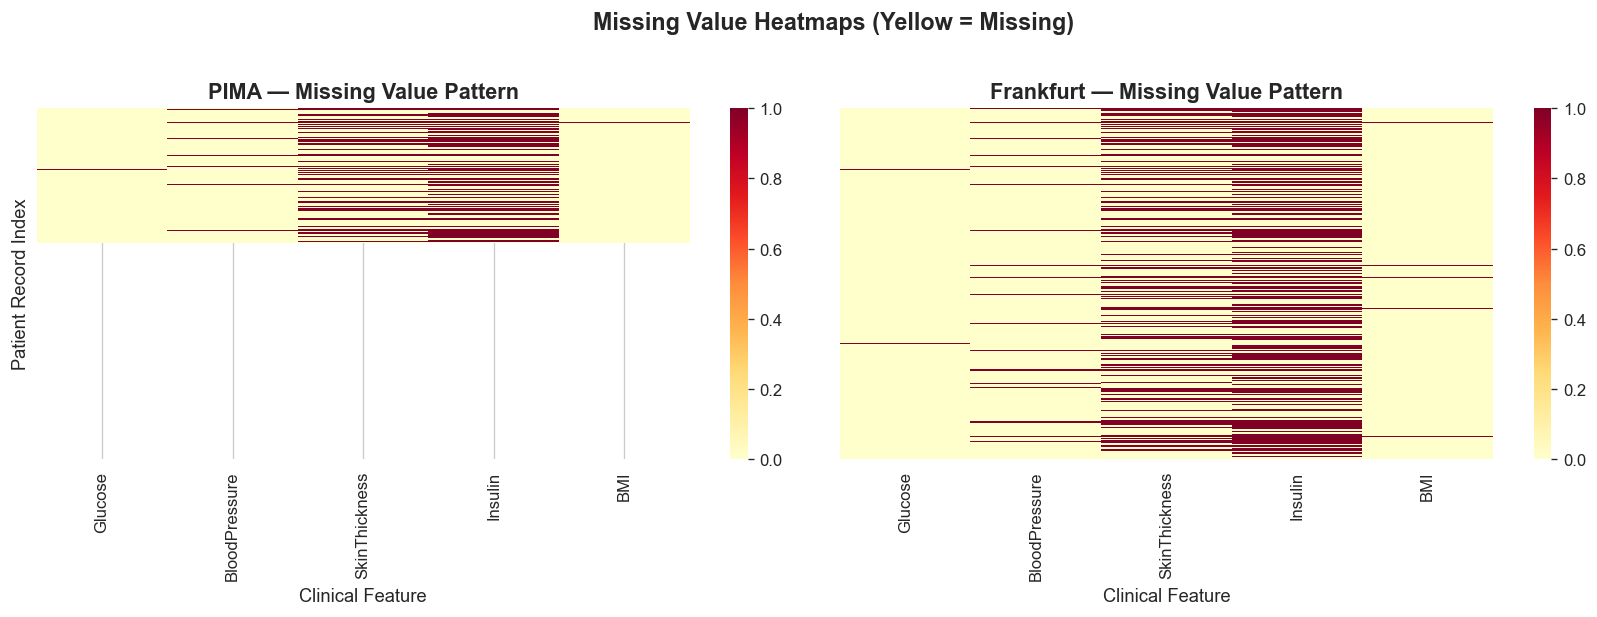

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.heatmap(df_pima[missing_zero_cols].isna(), cbar=True, ax=axes[0],
            cmap="YlOrRd", yticklabels=False)
axes[0].set_title("PIMA — Missing Value Pattern", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Clinical Feature", fontsize=11)
axes[0].set_ylabel("Patient Record Index", fontsize=11)
sns.heatmap(df_frankfurt[missing_zero_cols].isna(), cbar=True, ax=axes[1],
            cmap="YlOrRd", yticklabels=False)
axes[1].set_title("Frankfurt — Missing Value Pattern", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Clinical Feature", fontsize=11)
axes[1].set_ylabel("")
plt.suptitle("Missing Value Heatmaps (Yellow = Missing)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_3_1_1_missing_heatmap.png", bbox_inches="tight")
plt.show()

In [12]:
# Imputation — mean for normally distributed columns, median for skewed columns.
# Each dataset is imputed using its own statistics, before merging.
mean_cols   = ["Glucose", "BloodPressure"]
median_cols = ["BMI", "SkinThickness", "Insulin"]

for col in mean_cols:
    df_pima[col]      = df_pima[col].fillna(df_pima[col].mean())
    df_frankfurt[col] = df_frankfurt[col].fillna(df_frankfurt[col].mean())

for col in median_cols:
    df_pima[col]      = df_pima[col].fillna(df_pima[col].median())
    df_frankfurt[col] = df_frankfurt[col].fillna(df_frankfurt[col].median())

missing_after_imputation = pd.DataFrame({
    "PIMA_missing_after_imputation": df_pima[missing_zero_cols].isna().sum(),
    "Frankfurt_missing_after_imputation": df_frankfurt[missing_zero_cols].isna().sum()
})
print("\nMissing value counts after imputation (all zeros = success)")
display(missing_after_imputation)


Missing value counts after imputation (all zeros = success)


,PIMA_missing_after_imputation,Frankfurt_missing_after_imputation
Glucose,0,0
BloodPressure,0,0
SkinThickness,0,0
Insulin,0,0
BMI,0,0


### 3.2 Data Integration

In [13]:
# Data Integration
df_pima["source"] = "PIMA"
df_frankfurt["source"] = "Frankfurt"

df_combined = pd.concat([df_pima, df_frankfurt], axis=0, ignore_index=True)

print(f"Final integrated dataset shape: {df_combined.shape}")
print("\nSource distribution:")
display(df_combined["source"].value_counts().rename_axis("source").reset_index(name="count"))
print("\nClass distribution:")
display(df_combined[target_col].value_counts().sort_index()
        .rename_axis("Outcome").reset_index(name="count"))

# Drop source column before feature engineering and modelling
df_model = df_combined.drop(columns="source").copy()

Final integrated dataset shape: (2768, 10)

Source distribution:


,source,count
0,Frankfurt,2000
1,PIMA,768



Class distribution:


,Outcome,count
0,0,1816
1,1,952


In [14]:
df_combined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2768 entries, 0 to 2767
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2768 non-null   int64  
 1   Glucose                   2768 non-null   float64
 2   BloodPressure             2768 non-null   float64
 3   SkinThickness             2768 non-null   float64
 4   Insulin                   2768 non-null   float64
 5   BMI                       2768 non-null   float64
 6   DiabetesPedigreeFunction  2768 non-null   float64
 7   Age                       2768 non-null   int64  
 8   Outcome                   2768 non-null   int64  
 9   source                    2768 non-null   object 
dtypes: float64(6), int64(3), object(1)
memory usage: 216.4+ KB


In [15]:
df_combined.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000,2768.000000
mean,3.742775,121.895272,72.404086,29.205925,140.534682,32.593497,0.471193,33.132225,0.343931
std,3.323801,30.500962,11.988255,9.032220,82.912603,7.103476,0.325669,11.777230,0.475104
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,25.000000,120.000000,27.575000,0.244000,24.000000,0.000000
50%,3.000000,118.000000,72.000000,29.000000,126.000000,32.400000,0.375000,29.000000,0.000000
75%,6.000000,141.000000,80.000000,32.000000,130.000000,36.625000,0.624000,40.000000,1.000000
max,17.000000,199.000000,122.000000,110.000000,846.000000,80.600000,2.420000,81.000000,1.000000


### 3.3 Data Visualisation

#### Count Plot 

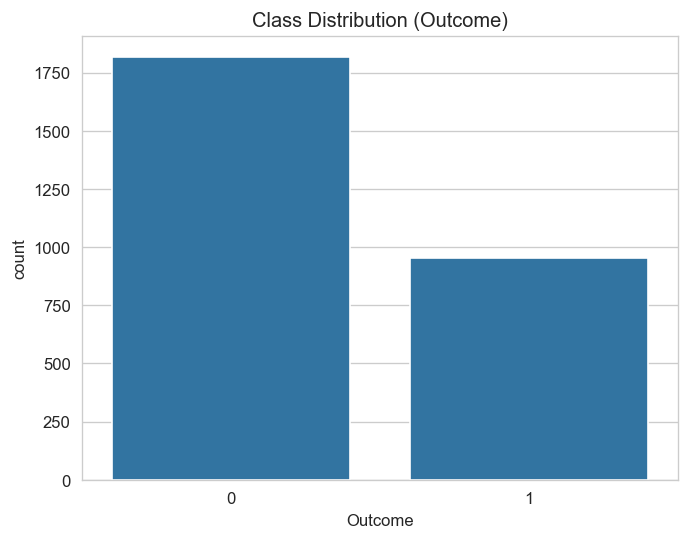

In [16]:
sns.countplot(x='Outcome', data=df_model)
plt.title("Class Distribution (Outcome)")
plt.savefig(FIG_DIR / "fig_3_3_1_eda_countplot.png", bbox_inches="tight")
plt.show()

#### Histograms 

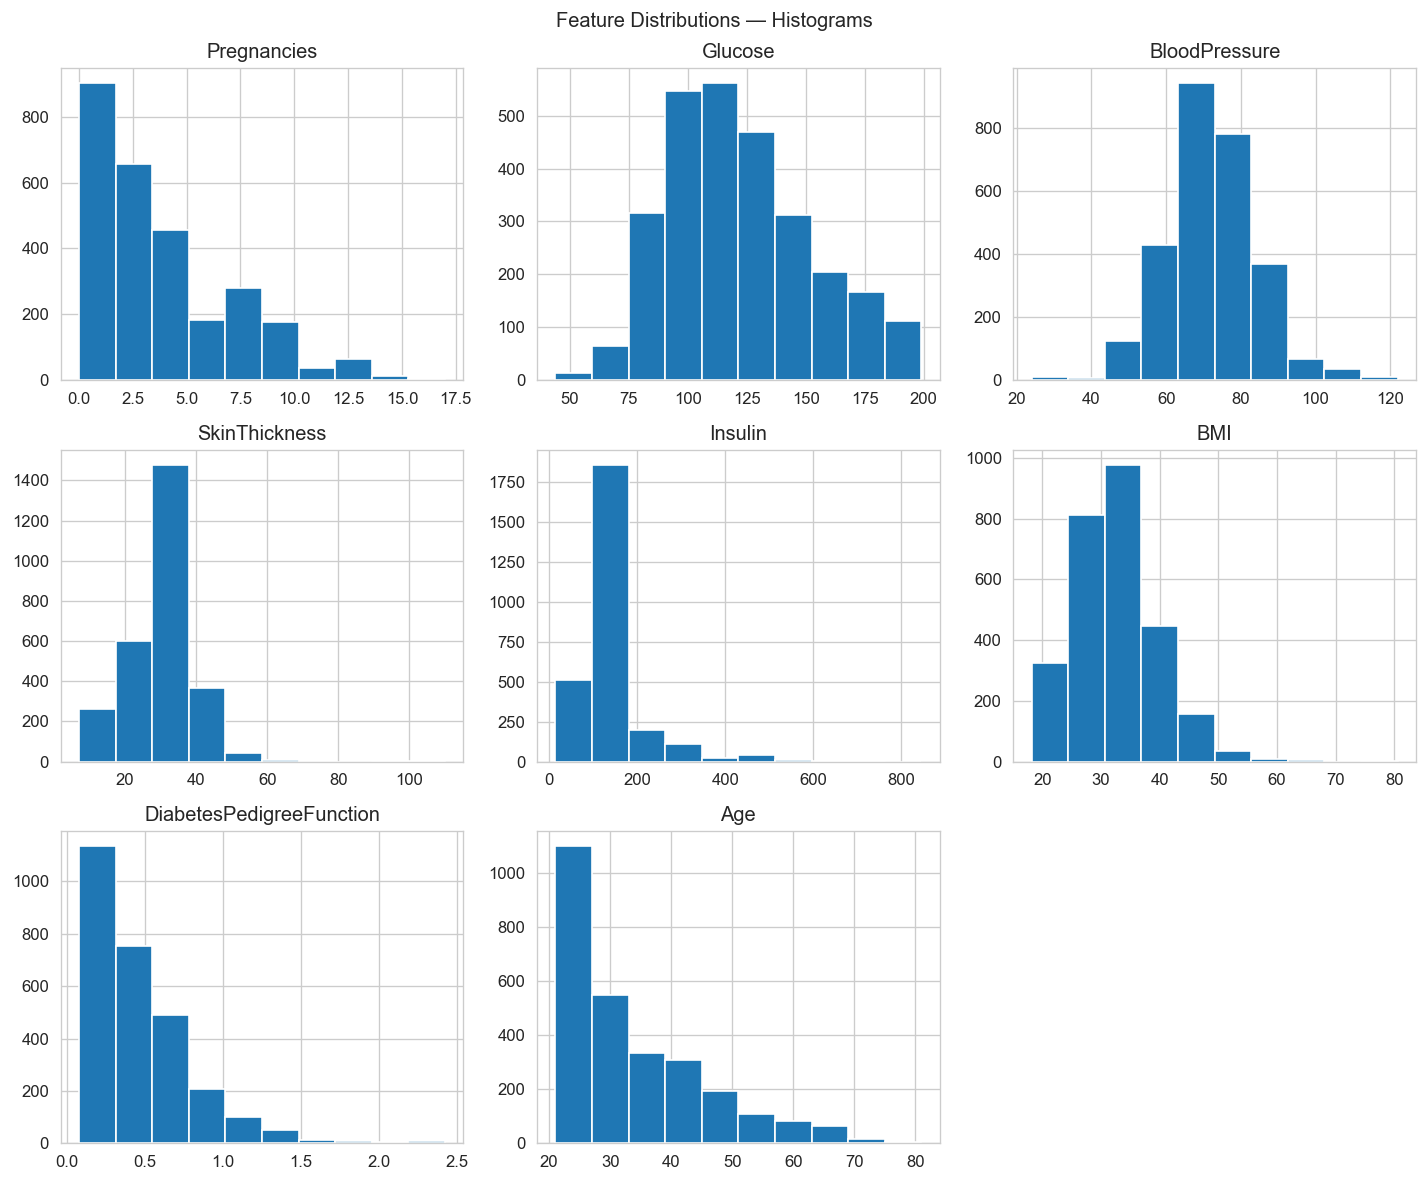

In [17]:
df_model[feature_cols].hist(bins=10, figsize=(12, 10))
plt.suptitle("Feature Distributions — Histograms")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_3_3_2_eda_histograms.png", bbox_inches="tight")
plt.show()

#### Box Plots 

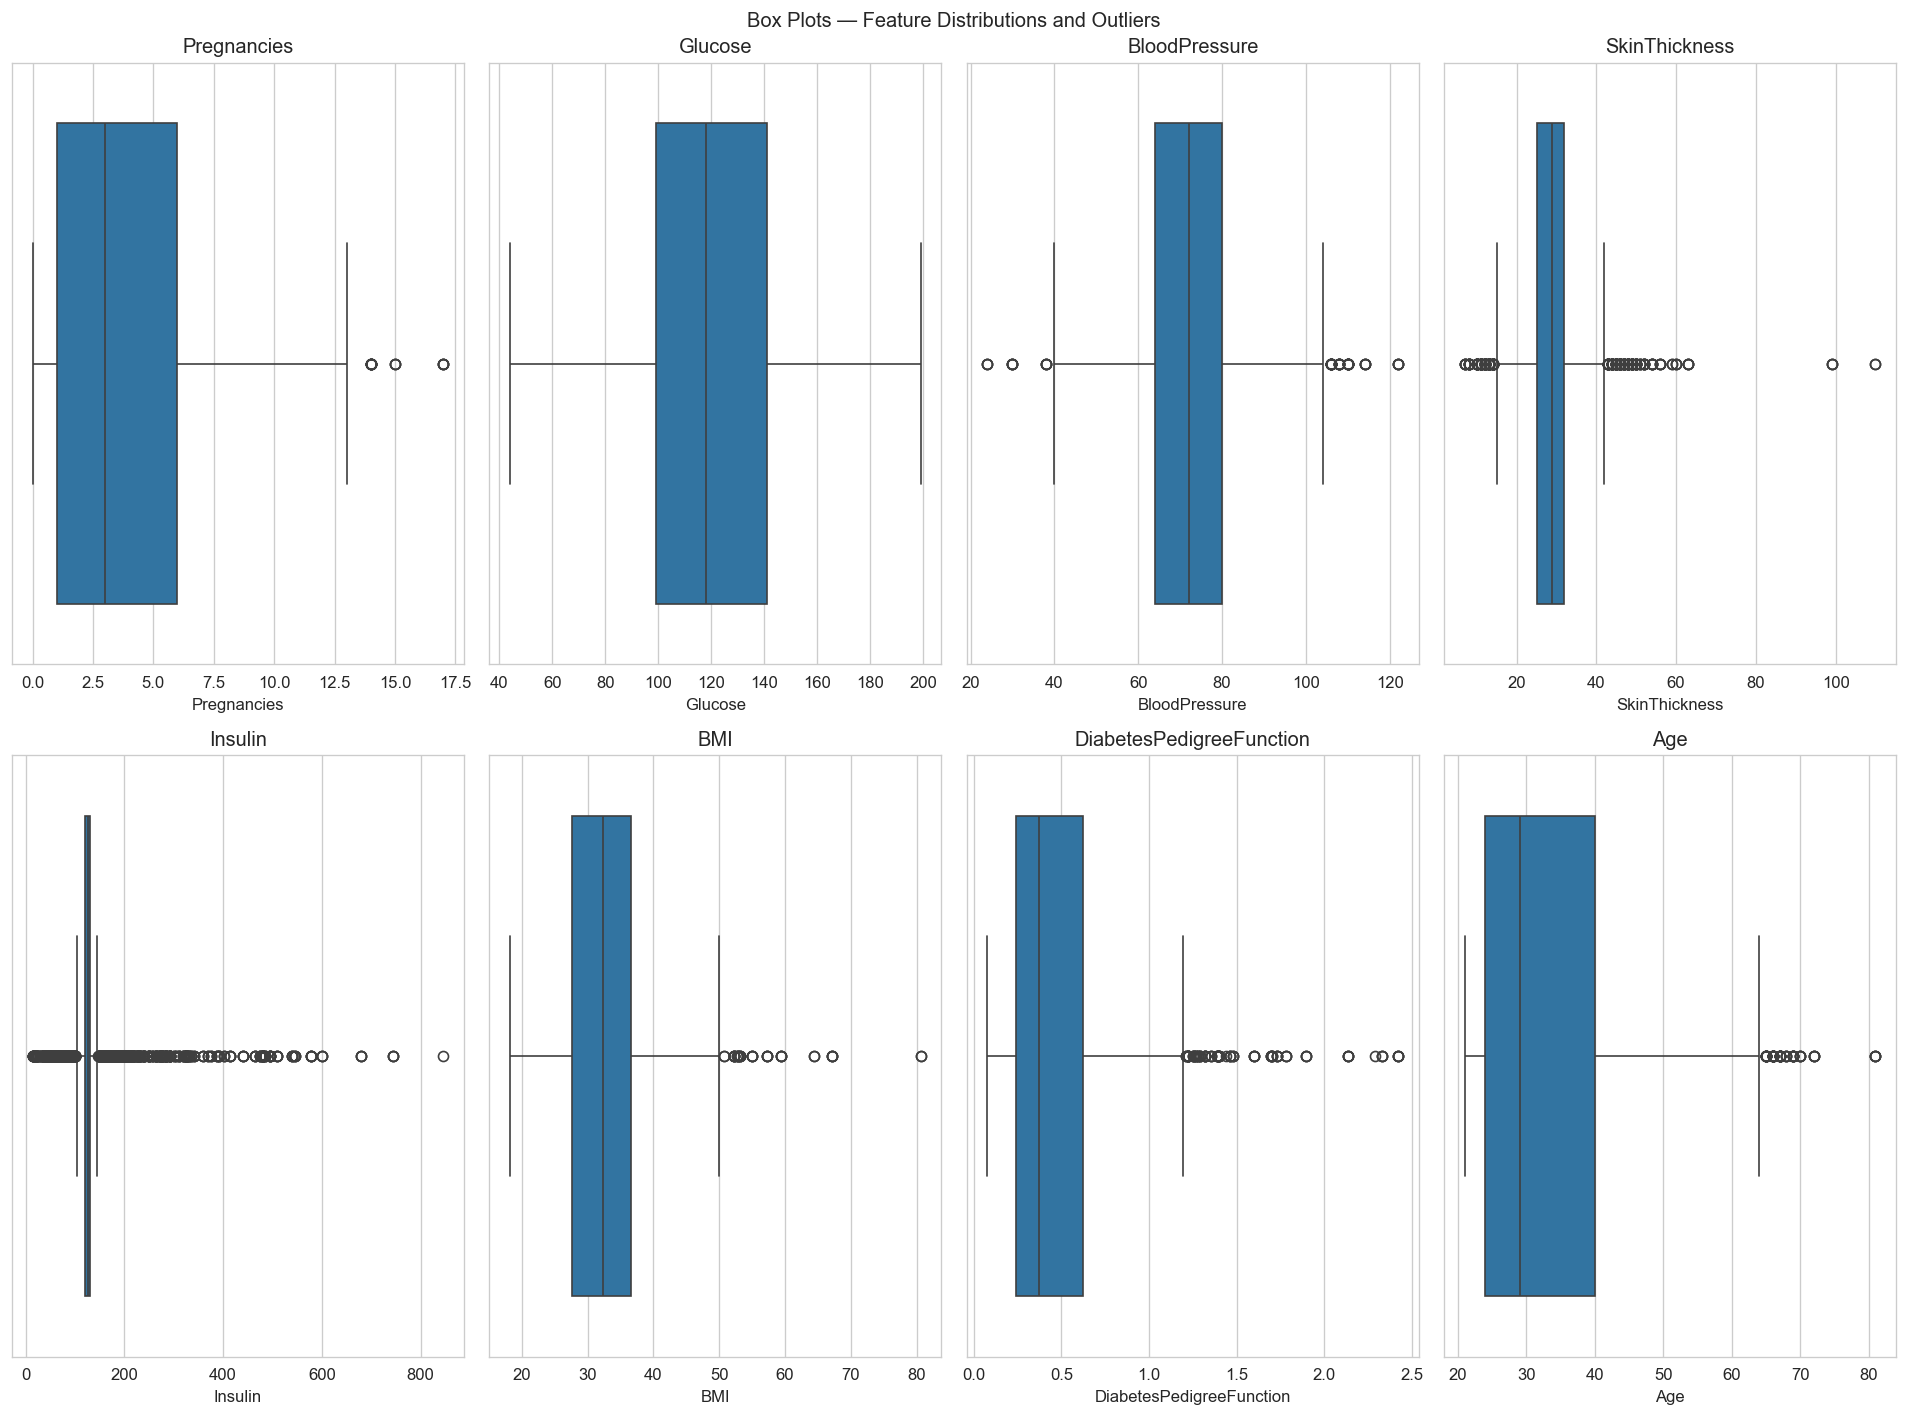

In [18]:
plt.figure(figsize=(16, 12))
sns.set_style(style='whitegrid')
for i, col in enumerate(feature_cols):
    plt.subplot(2, 4, i + 1)
    sns.boxplot(x=df_model[col])
    plt.title(col)
plt.suptitle("Box Plots — Feature Distributions and Outliers")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_3_3_3_eda_boxplots.png", bbox_inches="tight")
plt.show()

#### Scatter Matrix 

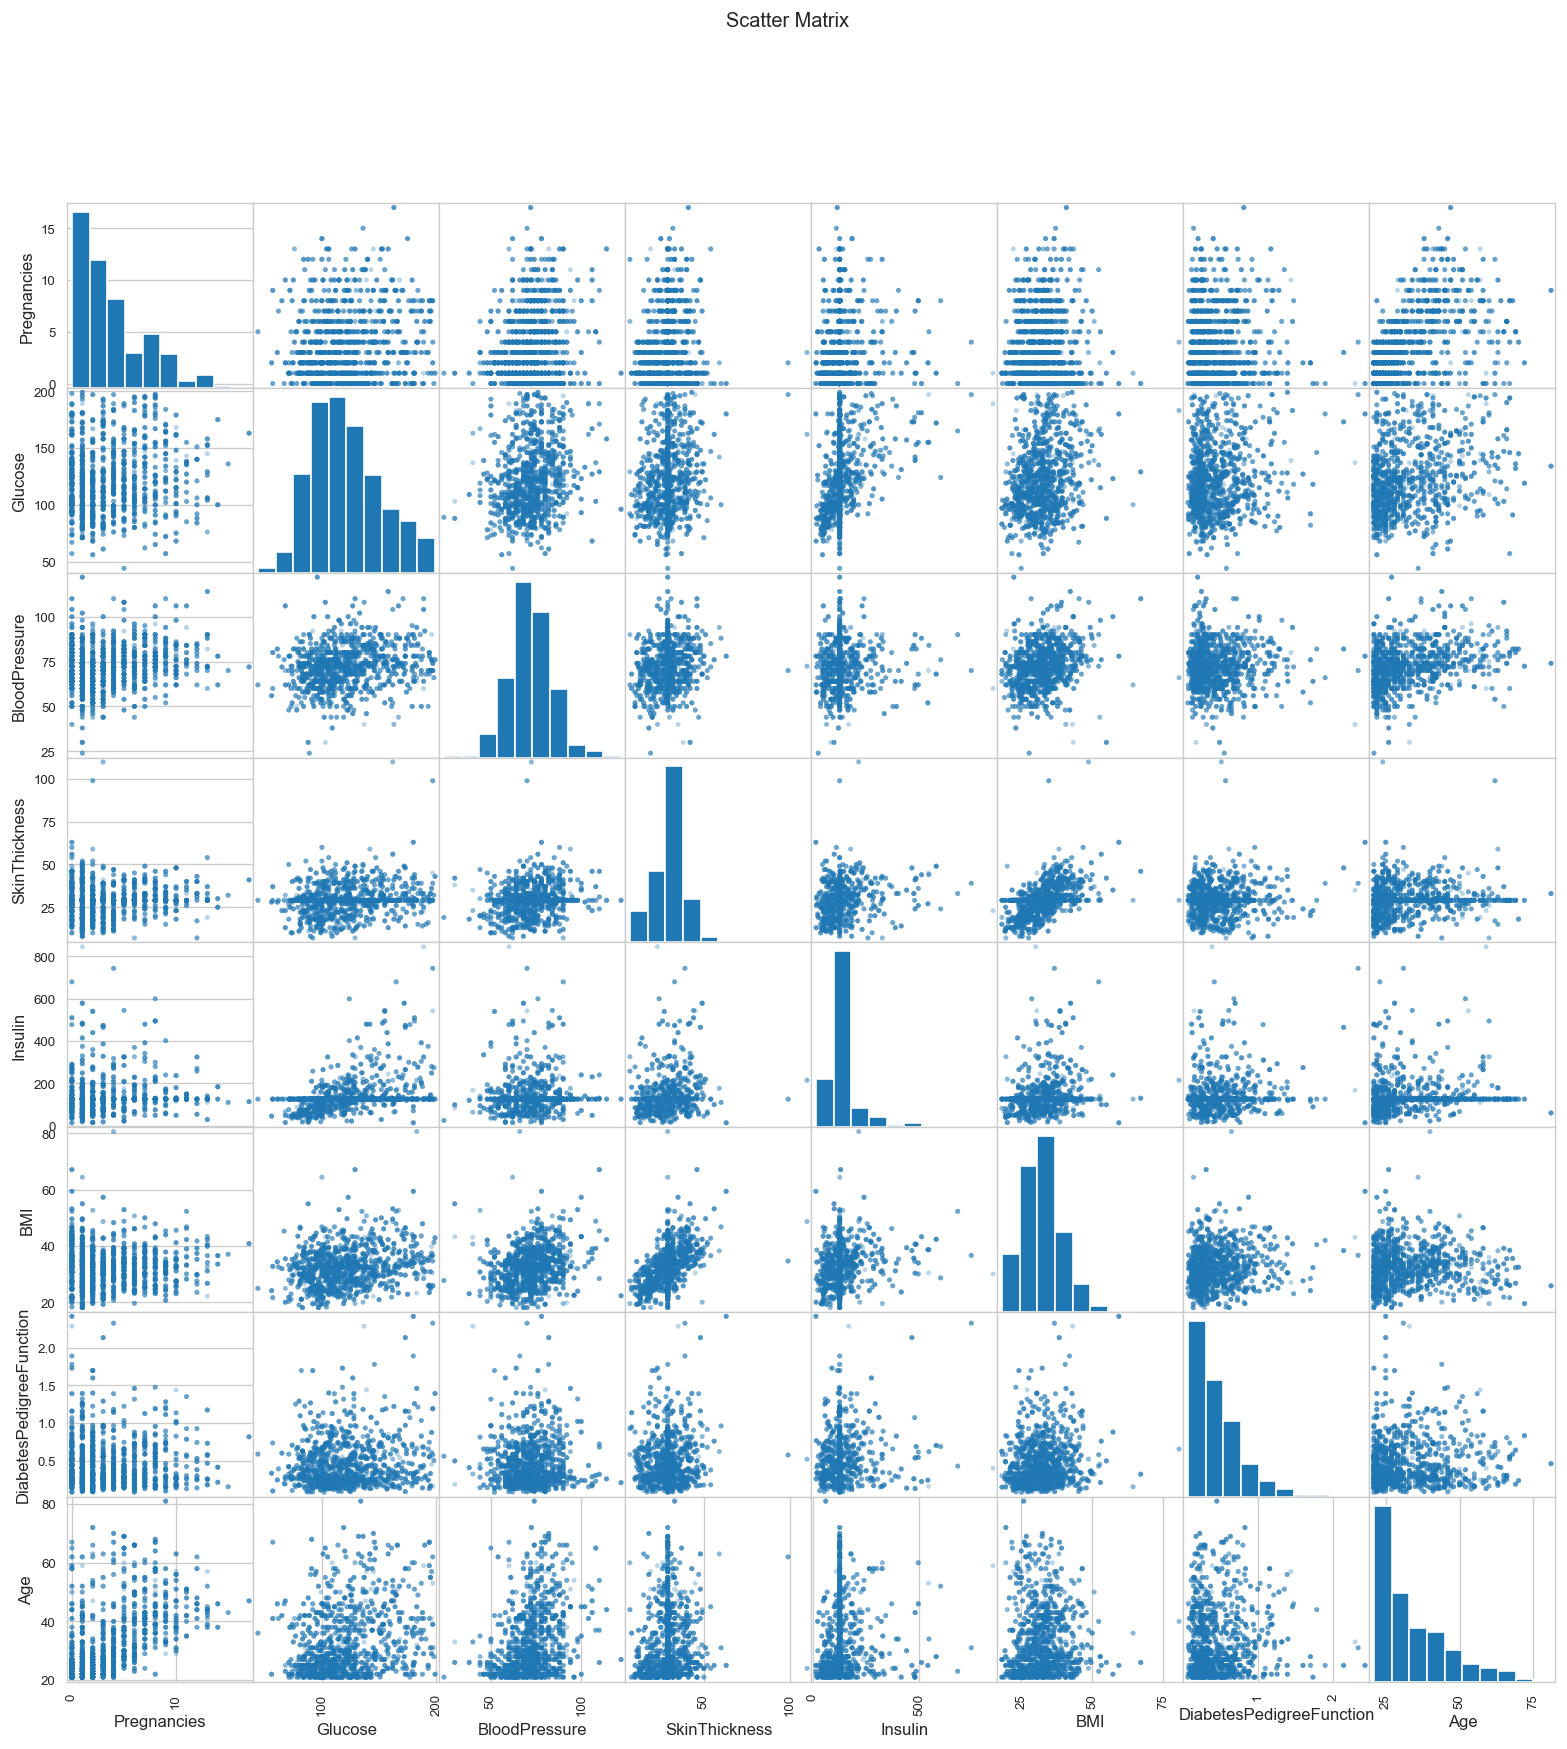

In [19]:
from pandas.plotting import scatter_matrix
scatter_matrix(df_model[feature_cols], figsize=(16, 16), alpha=0.3)
plt.suptitle("Scatter Matrix")
plt.savefig(FIG_DIR / "fig_3_3_4_eda_scatter_matrix.png", bbox_inches="tight")
plt.show()

### 3.4 Data Transformation 

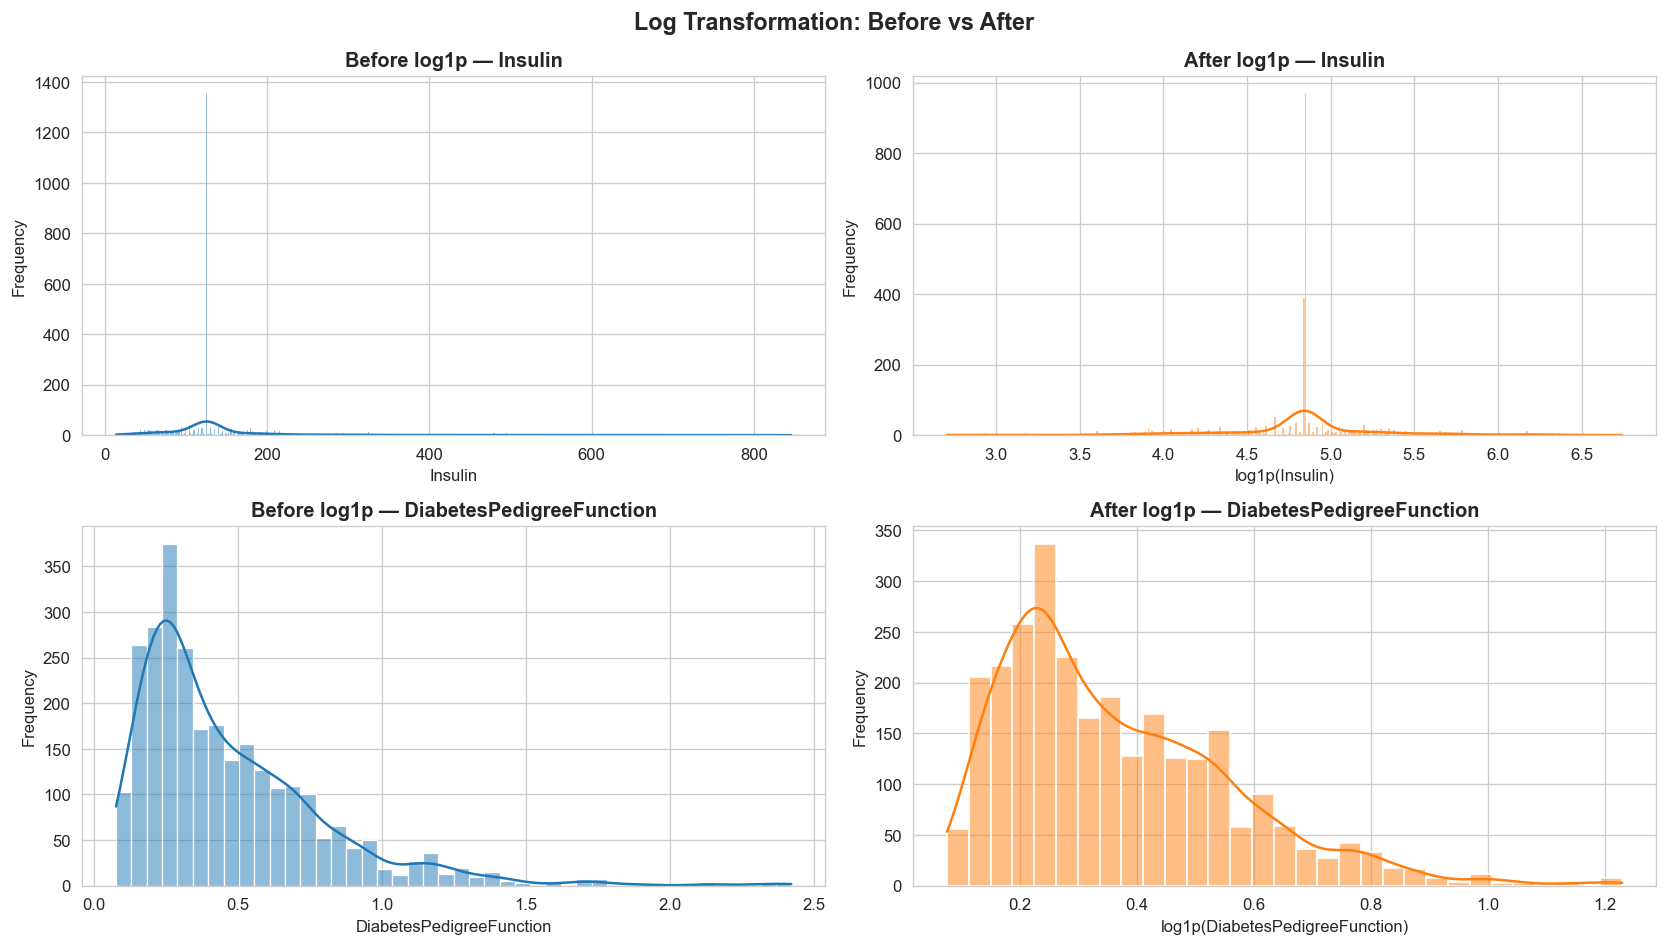

In [20]:
X_original = df_model[feature_cols].copy()
y = df_model[target_col].copy()

# Columns to apply log transformation (right-skewed distributions)
log_cols = ["Insulin", "DiabetesPedigreeFunction"]
X_transformed = X_original.copy()

# Save before/after data for visualisation
before_log = X_transformed[log_cols].copy()
for col in log_cols:
    X_transformed[col] = np.log1p(X_transformed[col])
after_log = X_transformed[log_cols].copy()

# Blue = before, orange = after
palette = sns.color_palette("tab10")
color_before = palette[0]
color_after  = palette[1]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for row, col in enumerate(log_cols):
    sns.histplot(before_log[col], kde=True, ax=axes[row, 0], color=color_before, edgecolor="white")
    axes[row, 0].set_title(f"Before log1p — {col}", fontsize=12, fontweight="bold")
    axes[row, 0].set_xlabel(col, fontsize=10)
    axes[row, 0].set_ylabel("Frequency", fontsize=10)

    sns.histplot(after_log[col], kde=True, ax=axes[row, 1], color=color_after, edgecolor="white")
    axes[row, 1].set_title(f"After log1p — {col}", fontsize=12, fontweight="bold")
    axes[row, 1].set_xlabel(f"log1p({col})", fontsize=10)
    axes[row, 1].set_ylabel("Frequency", fontsize=10)

plt.suptitle("Log Transformation: Before vs After", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_3_3_1_log_transform.png", bbox_inches="tight")
plt.show()

### 3.5 Data Standardisation

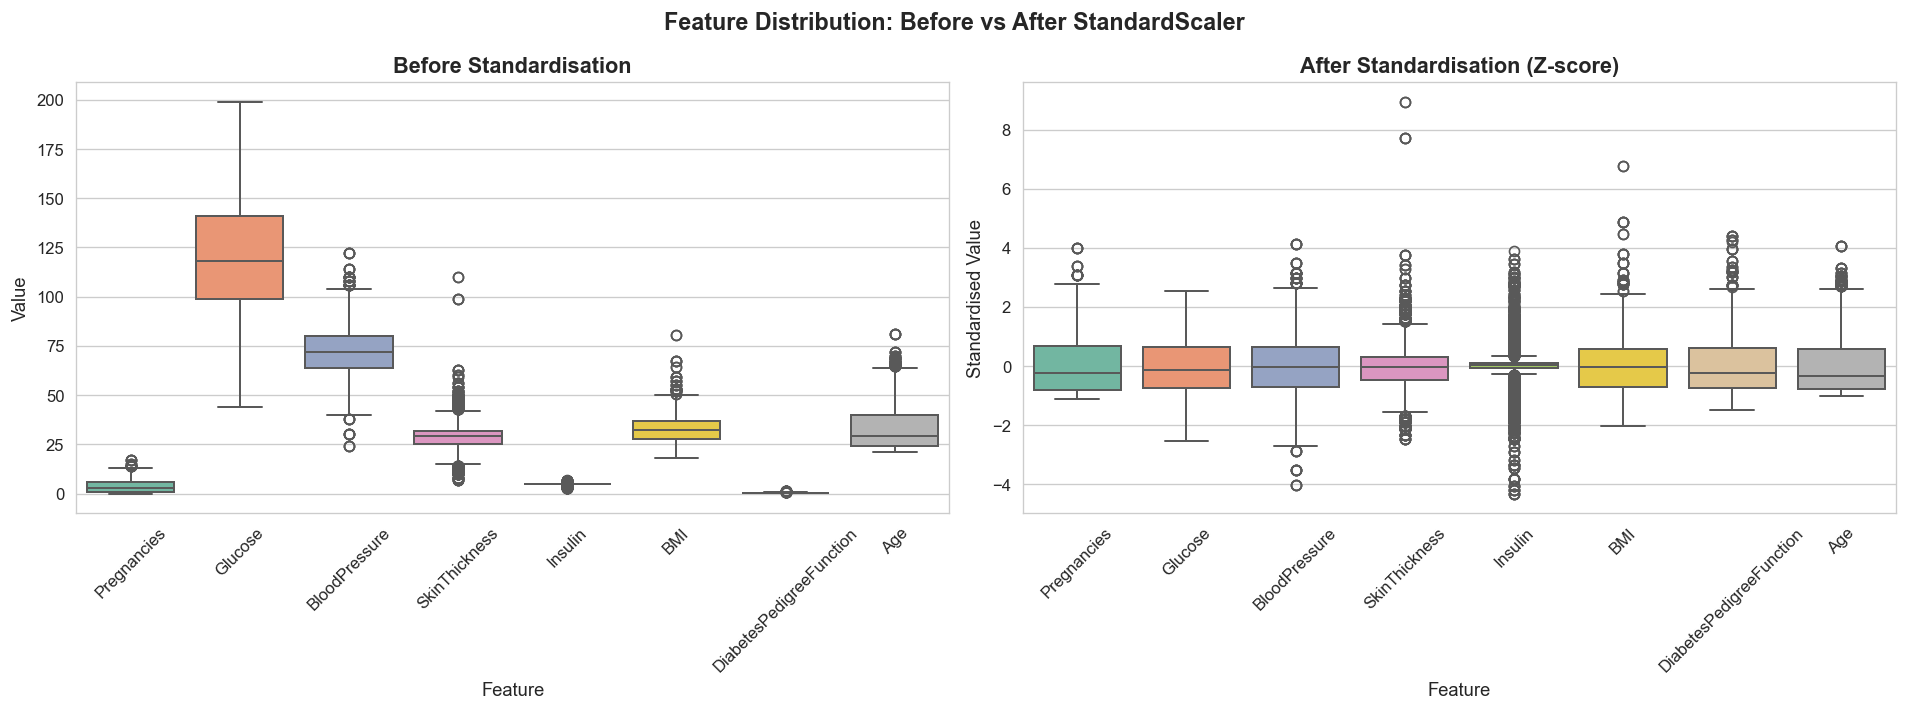

In [21]:
# Apply StandardScaler: transforms each feature to mean=0, std=1
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_transformed[feature_cols])
X_scaled = pd.DataFrame(X_scaled_array, columns=feature_cols)

# Boxplot before vs after standardisation
before_melted = X_transformed[feature_cols].melt(var_name="Feature", value_name="Value")
after_melted  = X_scaled.melt(var_name="Feature", value_name="Value")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(data=before_melted, x="Feature", y="Value", ax=axes[0], palette="Set2", linewidth=1.2)
axes[0].set_title("Before Standardisation", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Feature", fontsize=11)
axes[0].set_ylabel("Value", fontsize=11)
axes[0].tick_params(axis="x", rotation=45)
sns.boxplot(data=after_melted, x="Feature", y="Value", ax=axes[1], palette="Set2", linewidth=1.2)
axes[1].set_title("After Standardisation (Z-score)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Feature", fontsize=11)
axes[1].set_ylabel("Standardised Value", fontsize=11)
axes[1].tick_params(axis="x", rotation=45)
plt.suptitle("Feature Distribution: Before vs After StandardScaler", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_3_4_1_standardization.png", bbox_inches="tight")
plt.show()

In [22]:
# Verify scaling result: mean should be ~0, std should be ~1
print("Descriptive statistics after scaling (Expect Mean ≈ 0, Std ≈ 1):")
display(X_scaled.describe().round(4))

Descriptive statistics after scaling (Expect Mean ≈ 0, Std ≈ 1):


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,2768.0000,2768.0000,2768.0000,2768.0000,2768.0000,2768.0000,2768.0000,2768.0000
mean,0.0000,-0.0000,-0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000
std,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002,1.0002
min,-1.1263,-2.5543,-4.0384,-2.4590,-4.3201,-2.0266,-1.4777,-1.0303
25%,-0.8253,-0.7508,-0.7012,-0.4657,-0.0697,-0.7066,-0.7485,-0.7756
50%,-0.2235,-0.1277,-0.0337,-0.0228,0.0289,-0.0272,-0.2388,-0.3509
75%,0.6792,0.6265,0.6337,0.3094,0.0920,0.5676,0.6086,0.5832
max,3.9893,2.5284,4.1378,8.9467,3.8920,6.7594,4.4003,4.0652


# 4. Feature Selection

### 4.1 Mutual Information

In [24]:
from sklearn.feature_selection import mutual_info_classif

# Compute mutual information score between each feature and the target
mi_scores = mutual_info_classif(X_scaled, y, random_state=42)

# Organise into a DataFrame sorted from highest to lowest score
mi_df = (pd.DataFrame({"Feature": feature_cols, "MI Score": mi_scores})
         .sort_values("MI Score", ascending=False)
         .reset_index(drop=True))

print("Mutual Information Scores (sorted descending):")
display(mi_df.round(4))

Mutual Information Scores (sorted descending):


,Feature,MI Score
0,DiabetesPedigreeFunction,0.3510
1,BMI,0.1914
2,Glucose,0.1841
3,Insulin,0.1342
4,Age,0.0851
5,SkinThickness,0.0430
6,Pregnancies,0.0291
7,BloodPressure,0.0273


In [25]:
# Use the median MI score as the selection threshold
mi_threshold = mi_df["MI Score"].median()
mi_selected_features = mi_df.loc[mi_df["MI Score"] > mi_threshold, "Feature"].tolist()

print(f"Median MI score threshold: {mi_threshold:.4f}")
print("MI-selected features:", mi_selected_features)

Median MI score threshold: 0.1096
MI-selected features: ['DiabetesPedigreeFunction', 'BMI', 'Glucose', 'Insulin']


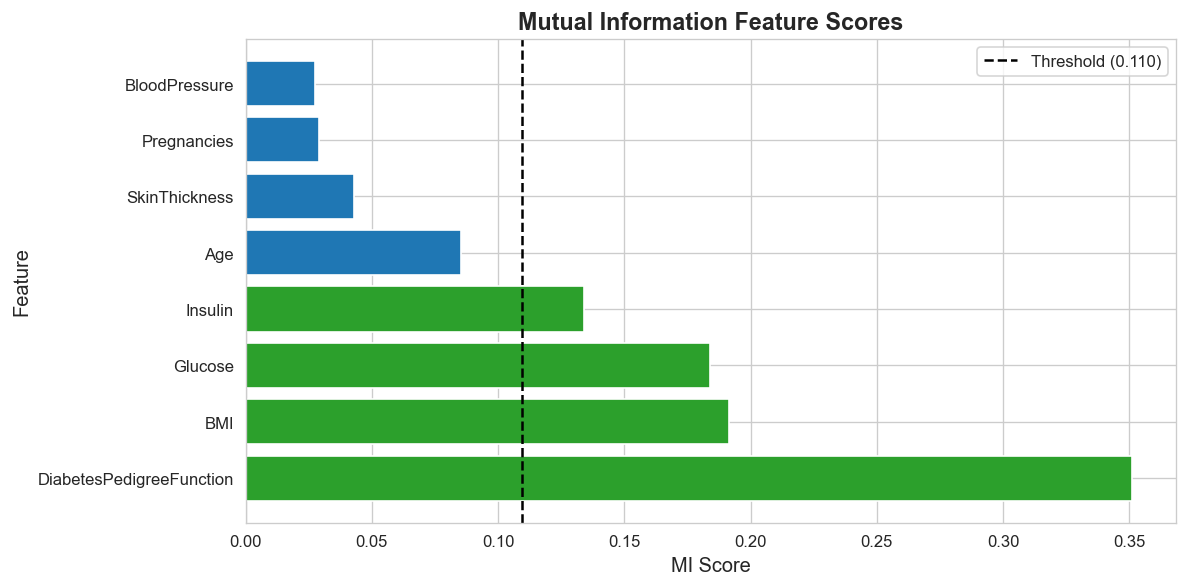

In [26]:
# Bar chart of MI scores — green = selected, blue = not selected
fig, ax = plt.subplots(figsize=(10, 5))
colors_mi = ['tab:green' if f in mi_selected_features else 'tab:blue' for f in mi_df["Feature"]]
ax.barh(mi_df["Feature"], mi_df["MI Score"], color=colors_mi, edgecolor="white")
ax.axvline(mi_threshold, color="black", linestyle="--", linewidth=1.5,
           label=f"Threshold ({mi_threshold:.3f})")
ax.set_title("Mutual Information Feature Scores", fontsize=14, fontweight="bold")
ax.set_xlabel("MI Score", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_4_2_1_mi_barplot.png", bbox_inches="tight")
plt.show()

### 4.2 Recursive Feature Elimination

In [27]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

# RFE requires an estimator with coef_ — Logistic Regression is used as the base
rfe_estimator = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=4)
rfe.fit(X_scaled, y)

# Collect support and ranking results
rfe_df = (pd.DataFrame({
    "Feature": feature_cols,
    "Selected": rfe.support_,
    "Ranking": rfe.ranking_
}).sort_values(["Ranking", "Feature"]).reset_index(drop=True))

print("RFE Feature Support and Ranking (Rank 1 = Selected):")
display(rfe_df)

RFE Feature Support and Ranking (Rank 1 = Selected):


,Feature,Selected,Ranking
0,BMI,True,1
1,DiabetesPedigreeFunction,True,1
2,Glucose,True,1
3,Pregnancies,True,1
4,Age,False,2
5,Insulin,False,3
6,SkinThickness,False,4
7,BloodPressure,False,5


In [28]:
rfe_selected_features = rfe_df.loc[rfe_df["Selected"], "Feature"].tolist()
print("RFE-selected features:", rfe_selected_features)

RFE-selected features: ['BMI', 'DiabetesPedigreeFunction', 'Glucose', 'Pregnancies']


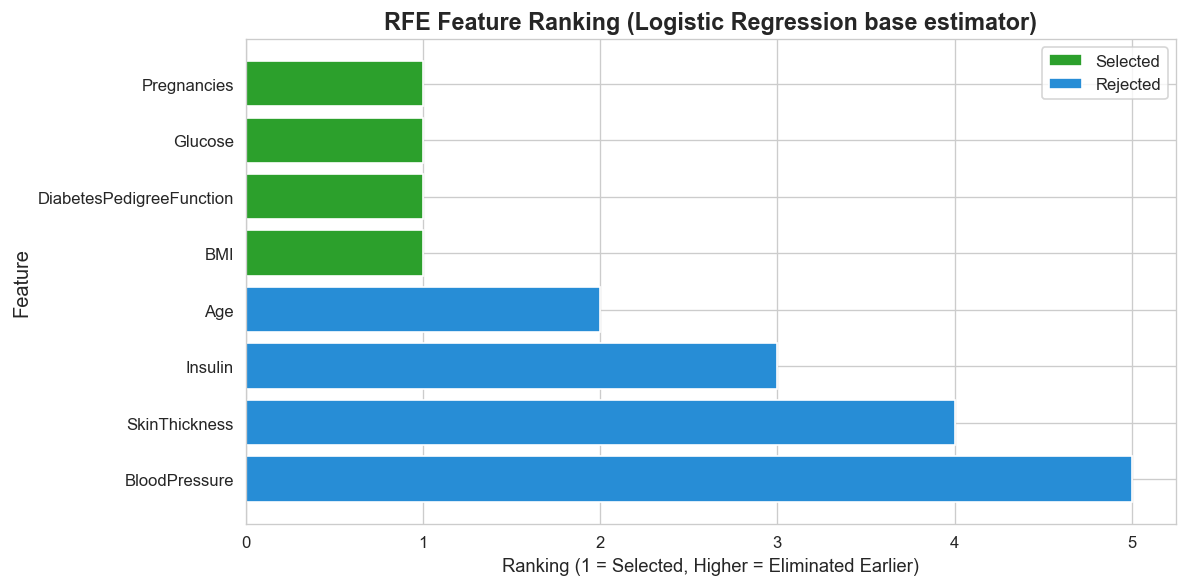

In [29]:
# Bar chart of RFE ranking — green = selected, blue = rejected
rfe_plot_df = rfe_df.sort_values("Ranking", ascending=False)
bar_colors = ['#2ca02c' if s else "#278dd6" for s in rfe_plot_df["Selected"]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(rfe_plot_df["Feature"], rfe_plot_df["Ranking"], color=bar_colors, edgecolor="white")
ax.set_title("RFE Feature Ranking (Logistic Regression base estimator)", fontsize=14, fontweight="bold")
ax.set_xlabel("Ranking (1 = Selected, Higher = Eliminated Earlier)", fontsize=11)
ax.set_ylabel("Feature", fontsize=12)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ca02c', label='Selected'),
                   Patch(facecolor='#278dd6', label='Rejected')]
ax.legend(handles=legend_elements, fontsize=10)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_4_3_1_rfe_ranking.png", bbox_inches="tight")
plt.show()

In [30]:
# Feature selection summary
print("Feature Selection Summary:")
print("-" * 30)
print(f"1. Mutual Information (MI) selected features ({len(mi_selected_features)}):")
print(mi_selected_features)
print(f"\n2. Recursive Feature Elimination (RFE) selected features ({len(rfe_selected_features)}):")
print(rfe_selected_features)
common_features = list(set(mi_selected_features) & set(rfe_selected_features))
print("-" * 30)
print(f"Features selected by both methods: {common_features}")

Feature Selection Summary:
------------------------------
1. Mutual Information (MI) selected features (4):
['DiabetesPedigreeFunction', 'BMI', 'Glucose', 'Insulin']

2. Recursive Feature Elimination (RFE) selected features (4):
['BMI', 'DiabetesPedigreeFunction', 'Glucose', 'Pregnancies']
------------------------------
Features selected by both methods: ['DiabetesPedigreeFunction', 'BMI', 'Glucose']


# 5. Model Performance 

In [31]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorers = {
    "Accuracy":  make_scorer(accuracy_score),
    "Precision": make_scorer(precision_score, zero_division=0),
    "Recall":    make_scorer(recall_score,    zero_division=0),
    "F1":        make_scorer(f1_score,        zero_division=0),
}

def evaluate_feature_set(name, selected_features):
    row = {"Scenario": name, "Features Used": ", ".join(selected_features)}
    for metric, scorer in scorers.items():
        scores = cross_val_score(model, X_scaled[selected_features], y,
                                 cv=cv, scoring=scorer)
        row[metric] = round(scores.mean(), 4)
    return row

performance_rows = [
    evaluate_feature_set("All Features (Baseline)", feature_cols),
    evaluate_feature_set("MI-Selected Features",    mi_selected_features),
    evaluate_feature_set("RFE-Selected Features",   rfe_selected_features),
]
performance_df = pd.DataFrame(performance_rows)
print("KNN Model Performance — 5-Fold Stratified Cross-Validation (k=5)")
display(performance_df[["Scenario", "Accuracy", "Precision", "Recall", "F1", "Features Used"]])

KNN Model Performance — 5-Fold Stratified Cross-Validation (k=5)


,Scenario,Accuracy,Precision,Recall,F1,Features Used
0,All Features (Baseline),0.8425,0.7634,0.7879,0.7750,"Pregnancies, Glucose, BloodPressure, SkinThick..."
1,MI-Selected Features,0.8284,0.7489,0.7553,0.7517,"DiabetesPedigreeFunction, BMI, Glucose, Insulin"
2,RFE-Selected Features,0.8382,0.7611,0.7721,0.7663,"BMI, DiabetesPedigreeFunction, Glucose, Pregna..."


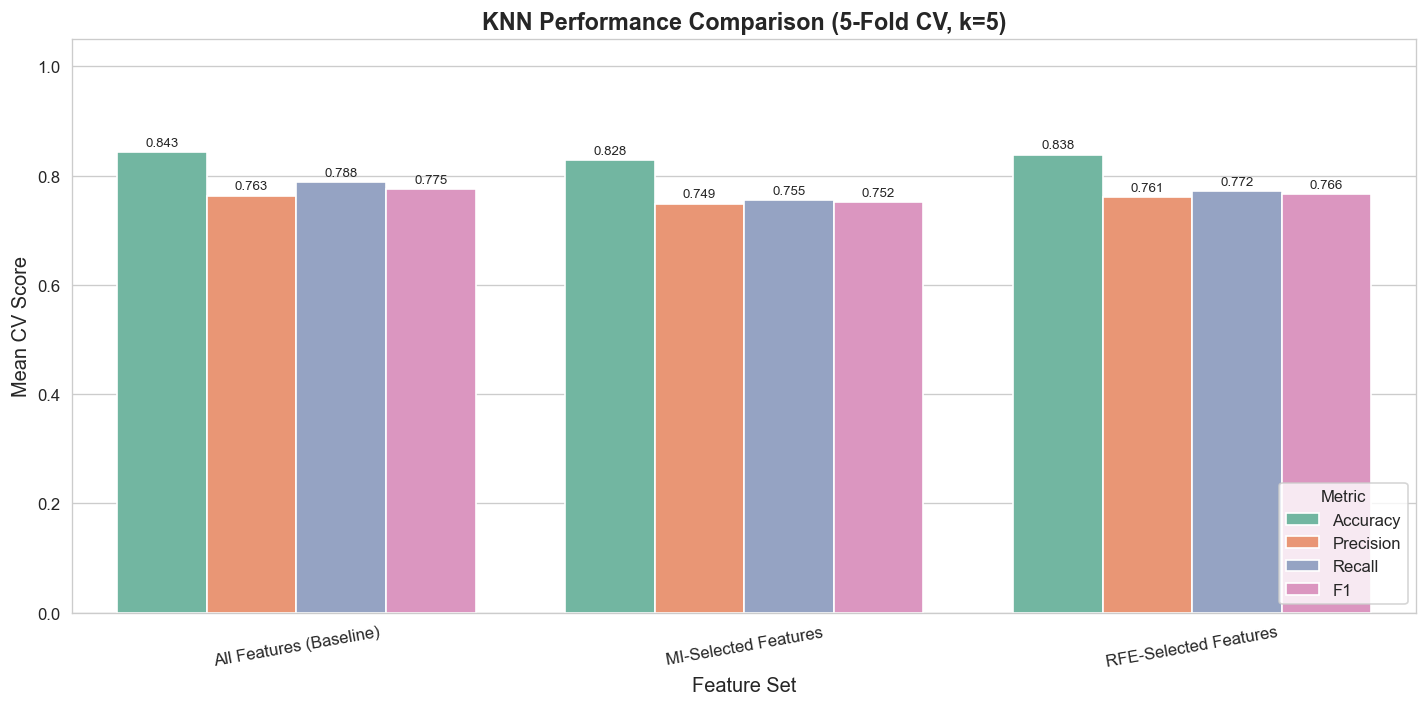

In [32]:
# Grouped bar chart
plot_df = performance_df.melt(
    id_vars=["Scenario", "Features Used"],
    value_vars=["Accuracy", "Precision", "Recall", "F1"],
    var_name="Metric", value_name="Score"
)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=plot_df, x="Scenario", y="Score", hue="Metric",
            ax=ax, palette="Set2", edgecolor="white")
ax.set_ylim(0, 1.05)
ax.set_title("KNN Performance Comparison (5-Fold CV, k=5)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Feature Set", fontsize=12)
ax.set_ylabel("Mean CV Score", fontsize=12)
ax.tick_params(axis="x", rotation=10)
ax.legend(title="Metric", fontsize=10, title_fontsize=10, loc="lower right")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_5_1_performance_comparison.png", bbox_inches="tight")
plt.show()

In [33]:
# Save preprocessed scaled data
preprocessed_output = X_scaled.copy()
preprocessed_output[target_col] = y.reset_index(drop=True)
preprocessed_output.to_csv(OUTPUT_DIR / "preprocessed_dataset.csv", index=False)

print(f"\nSaved preprocessed dataset to: {OUTPUT_DIR / 'preprocessed_dataset.csv'}")
print(f"Saved figures to: {FIG_DIR}")


Saved preprocessed dataset to: output/preprocessed_dataset.csv
Saved figures to: output/figures
